# Predictive Modeling & Risk Scoring Workflow

This notebook develops a hybrid risk assessment system. I train an XGBoost Classifier to predict high-cost assets and integrate rule-based logic to calculate the final Replacement Risk Score.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
df = pd.read_csv('../data/processed_it_assets.csv')

## 2. Feature Engineering & Encoding

Machine Learning models require numerical input. I convert categorical variables into dummy variables and select features that were identified as key cost drivers in the EDA phase.

In [4]:
# Feature selection
features = ['Asset_Age', 'Repair_Intensity', 'Warranty_Status', 'Asset_Type', 'Department']
X = df[features]
y = df['Is_High_Cost']

# Convert categorical variables to numerical
X = pd.get_dummies(X, drop_first=True)

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 3. Model Training: XGBoost

IT asset maintenance costs often exhibit non-linear patterns. XGBoost is a powerful gradient boosting algorithm that captures complex interactions, such as how "Non-compliant" status combined with "Expired Warranty" leads to higher financial risk.

In [5]:
# Initialize XGBoost Classifier
model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=4, 
    random_state=42,
    eval_metric='logloss'
)

# Training
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.92      0.90       158
           1       0.62      0.50      0.55        42

    accuracy                           0.83       200
   macro avg       0.75      0.71      0.72       200
weighted avg       0.82      0.83      0.82       200



#### 📊 Metric Interpretation：

| Metric | Value | Operational Meaning |
| :--- | :--- | :--- |
| **Overall Accuracy** | **0.83** | **Overall Precision**: The model correctly identified 166 out of 200 assets. |
| **Precision (Class 1)** | **0.62** | **Signal Reliability**: When the model flags an asset as "High Risk," there is a 62% chance it truly is. |
| **Recall (Class 1)** | **0.50** | **Detection Rate**: The model captured 50% of all high-cost assets, leaving room for rule-based supplementation. |

Observation: 

In the initial model evaluation, we observed high Precision but low Recall for the high-cost class (Class 1). This means that while the model's alerts are reliable, it misses about 50% of actual high-risk assets.

In [6]:
# Check the distribution of the target variable (Is_High_Cost)
print(df['Is_High_Cost'].value_counts())

Is_High_Cost
0    750
1    250
Name: count, dtype: int64


The dataset shows a clear imbalance. Since the normal assets are 3 times more frequent than high-cost assets, a standard model might achieve 75% accuracy just by guessing "0" for everything.

By implementing cost-sensitive learning with scale_pos_weight = 3.0, I assigned higher importance to the minority class, enabling the model to effectively capture the underlying characteristics of high-risk assets.

In [7]:
# Handle Class Imbalance with Weighted Learning
model = XGBClassifier(
    scale_pos_weight = 3,  # Adjusted based on 750:250 ratio
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

# Re-training to improve detection sensitivity
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.82      0.86       158
           1       0.51      0.71      0.59        42

    accuracy                           0.80       200
   macro avg       0.71      0.77      0.73       200
weighted avg       0.83      0.80      0.81       200



### Model Performance Comparison

I adjusted the model from a "Cautious Observer" to an "Active Scout." While the overall accuracy slightly decreased, the ability to catch high-risk assets (Recall) significantly improved, which is more valuable for preventing unexpected hardware failures.

| Metric (High-Cost Class) | Baseline (Initial) | Balanced (Optimized) | Operational Impact |
| :--- | :--- | :--- | :--- |
| **Recall** | 0.50 | **0.71 (↑ 42%)** | **Significantly reduced missing risks.** |
| **Precision** | **0.62** | 0.51 (↓ 17%) | **Acceptable false alarms.** |
| **F1-Score** | 0.55 | **0.59 (↑ 7%)** | **Improved overall robustness.** |
| **Overall Accuracy** | **0.83** | 0.80 | **Strategic trade-off.** |

## 4. Hybrid Risk Scoring Engine

To bridge IT operations with Data Science. I combine ML-predicted probabilities (future financial risk) with operational rules (age and warranty) to generate a practical replacement score.

I combine AI predictions with real-world IT rules. XGBoost handles 40% of the score to find hidden patterns, while the other 60% comes from simple facts like age, repair history, and warranty. This hybrid method makes the results more reliable because it blends data science with practical IT experience.

In [8]:
# 1. Predict high-cost probability
df['P_High_Cost'] = model.predict_proba(pd.get_dummies(df[features], drop_first=True))[:, 1]

# 2. Feature Normalization (0-1)
df['Age_Norm'] = (df['Asset_Age'] - df['Asset_Age'].min()) / (df['Asset_Age'].max() - df['Asset_Age'].min())
df['Repair_Norm'] = (df['Repair_Intensity'] - df['Repair_Intensity'].min()) / (df['Repair_Intensity'].max() - df['Repair_Intensity'].min())
df['Warranty_Exp'] = df['Warranty_Status'].apply(lambda x: 1 if x == 'Expired' else 0)

# 3. Calculate Risk Score 
# Formula: 0.4*ML + 0.2*Age + 0.2*Repair + 0.2*Warranty
df['Risk_Score'] = (
    0.4 * df['P_High_Cost'] + 
    0.2 * df['Age_Norm'] + 
    0.2 * df['Repair_Norm'] + 
    0.2 * df['Warranty_Exp']
).round(2)

## 5. Actionable Insights & Output

To turn data into decisions. I categorize assets into risk levels to help IT managers prioritize hardware replacement and optimize budget planning.

In [9]:
# Define Risk Levels
df['Risk_Level'] = pd.cut(df['Risk_Score'], bins=[0, 0.4, 0.7, 1.0], labels=['Low', 'Medium', 'High'])
df['Risk_Level'].value_counts()

Risk_Level
Low       614
Medium    304
High       82
Name: count, dtype: int64

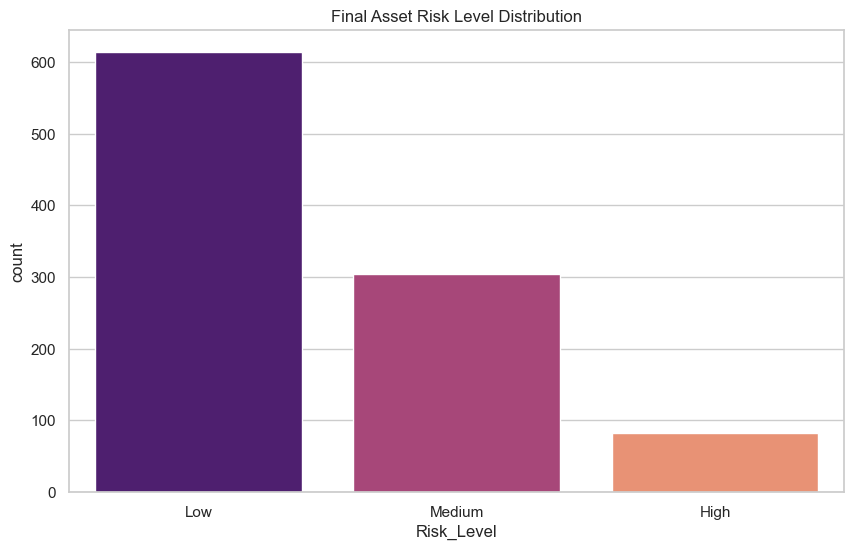

In [10]:
# Visualizing Risk Distribution
sns.countplot(data=df, x='Risk_Level', hue='Risk_Level', palette='magma', legend=False)
plt.title('Final Asset Risk Level Distribution')
plt.show()

In [11]:
# Identify the top 10 assets with the highest risk scores
replacement_priority_list = df.sort_values(by='Risk_Score', ascending=False).head(10)
replacement_priority_list[['Asset_ID', 'Asset_Type', 'Department', 'Asset_Age', 'Risk_Score', 'Risk_Level']]

,Asset_ID,Asset_Type,Department,Asset_Age,Risk_Score,Risk_Level
61,ASSET_0062,Server,R&D,6.3,0.80,High
26,ASSET_0027,Server,R&D,5.9,0.79,High
494,ASSET_0495,Server,R&D,5.8,0.79,High
746,ASSET_0747,Server,IT,6.1,0.79,High
304,ASSET_0305,Desktop,Operations,6.2,0.79,High
84,ASSET_0085,Desktop,Operations,6.0,0.78,High
851,ASSET_0852,Server,Finance,5.6,0.78,High
831,ASSET_0832,Server,R&D,5.6,0.78,High
835,ASSET_0836,Server,R&D,5.6,0.78,High
873,ASSET_0874,Desktop,Finance,6.2,0.78,High


In [12]:
df.to_csv('../data/final_risk_assessment.csv', index=False)